TensorFlow Version: 2.19.0
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Shape: (50000, 32, 32, 3)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3072)           │       396,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 32, 32, 3)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 806,208 (3.08 MB)

 Trainable params: 806,208 (3.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - loss: 0.0325 - val_loss: 0.0231
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 0.0195 - val_loss: 0.0175
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: 0.0166 - val_loss: 0.0158
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 0.0154 - val_loss: 0.0151
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - loss: 0.0147 - val_loss: 0.0144
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 0.0143 - val_loss: 0.0141
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - loss: 0.0140 - val_loss: 0.0139
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 0.0136 - val_loss: 0.0139
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - loss: 0.0132 - val_loss: 0.0131
Epoch 10/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - loss: 0.0129 - val_loss: 0.0128


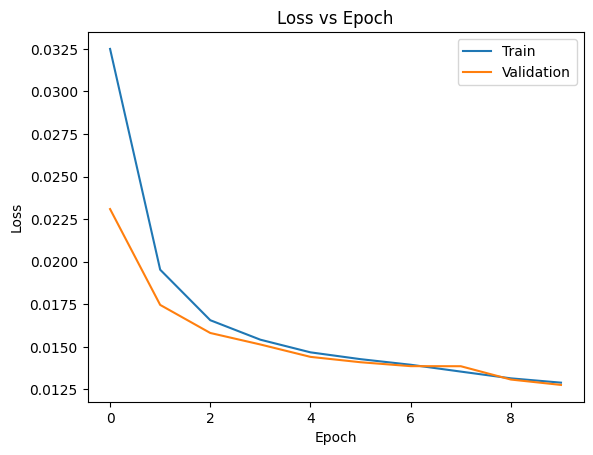

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


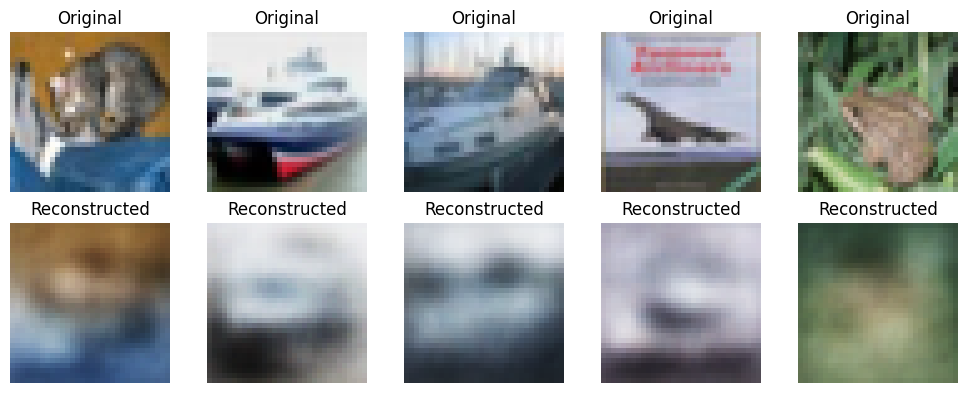

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


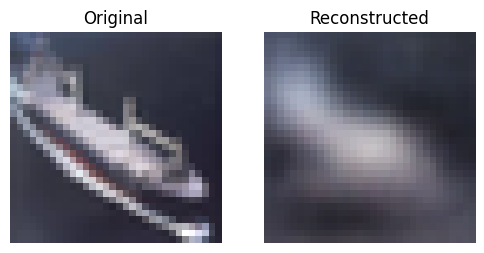

In [1]:
# ==========================================
# STEP 1: Import Libraries
# ==========================================
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow Version:", tf.__version__)

# ==========================================
# STEP 2: Load DIFFERENT Dataset
# ==========================================
(x_train, _), (x_test, _) = keras.datasets.cifar10.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Shape:", x_train.shape)

# ==========================================
# STEP 3: Build Autoencoder
# ==========================================
input_img = keras.Input(shape=(32, 32, 3))

# Encoder
x = keras.layers.Flatten()(input_img)
x = keras.layers.Dense(128, activation='relu')(x)
encoded = keras.layers.Dense(64, activation='relu')(x)

# Decoder
x = keras.layers.Dense(128, activation='relu')(encoded)
x = keras.layers.Dense(32*32*3, activation='sigmoid')(x)
decoded = keras.layers.Reshape((32, 32, 3))(x)

# Model
autoencoder = keras.Model(input_img, decoded)

autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

autoencoder.summary()

# ==========================================
# STEP 4: Train Model
# ==========================================
history = autoencoder.fit(
    x_train, x_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, x_test)
)

# ==========================================
# STEP 5: Plot Loss Graph (SAME STYLE)
# ==========================================
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.title("Loss vs Epoch")
plt.show()

# ==========================================
# STEP 6: Reconstruction
# ==========================================
decoded_imgs = autoencoder.predict(x_test)

# ==========================================
# STEP 7: Show Original vs Reconstructed
# ==========================================
n = 5
plt.figure(figsize=(10,4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i])
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()

# ==========================================
# STEP 8: Random Image Reconstruction
# ==========================================
idx = np.random.randint(0, len(x_test))

original = x_test[idx]
reconstructed = autoencoder.predict(original.reshape(1,32,32,3))

plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(original)
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(reconstructed[0])
plt.title("Reconstructed")
plt.axis('off')

plt.show()